# 02 — Hand-designed baseline: first training (preliminary)

A first, hand-written training of the baseline network `[64, 64]` on the windows built in `01_data.ipynb`. Its purpose was to set up the training loop and the evaluation metrics (ROC curve, AUC, precision–recall curve, AP).

**This notebook is preliminary and its numbers are not used in the report.** It follows an earlier protocol: 20 epochs, the weights of the last epoch, no fixed seed. In the report the baseline is trained with the common protocol of `03_nas.ipynb` (epoch selected on the validation AUC, early stopping, fixed seeds), exactly like every other architecture.

**Input:** `dataset_finestre.npz`. **Outputs:** none.

## 1. Data

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, precision_score, recall_score)
import matplotlib.pyplot as plt

# Windows built and normalised in 01_data.ipynb
d = np.load("dataset_finestre.npz")
X_train, y_train = d["X_train"], d["y_train"]
X_val,   y_val   = d["X_val"],   d["y_val"]
X_test,  y_test  = d["X_test"],  d["y_test"]
X_cav_test = d["X_cav_test"]
mu, sigma = d["mu"], d["sigma"]
FEATURE_COLS = list(d["feature_cols"])

print("Train:", X_train.shape, "| positivi:", int(y_train.sum()))
print("Val:  ", X_val.shape,   "| positivi:", int(y_val.sum()))
print("Test: ", X_test.shape,  "| positivi:", int(y_test.sum()))
print("Controllo (a cavallo):", X_cav_test.shape)
print("Feature:", FEATURE_COLS)

Train: (47573, 30, 4) | positivi: 4543
Val:   (28868, 30, 4) | positivi: 535
Test:  (27920, 30, 4) | positivi: 436
Controllo (a cavallo): (468, 30, 4)
Feature: [np.str_('Local_X'), np.str_('v_lat'), np.str_('v_Vel'), np.str_('v_Acc')]


In [2]:
# Device: the GPU of the Mac (MPS) if available, otherwise the CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Dispositivo:", device)

# numpy -> PyTorch tensors (float32 is the standard type for networks)
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32)
Xva = torch.tensor(X_val,   dtype=torch.float32)
yva = torch.tensor(y_val,   dtype=torch.float32)

print("Xtr:", Xtr.shape, "| ytr:", ytr.shape)

Dispositivo: mps
Xtr: torch.Size([47573, 30, 4]) | ytr: torch.Size([47573])


## 2. Model

A multilayer perceptron with two hidden layers of 64 units. The window (30 frames × 4 features) is flattened into a vector of 120 inputs; the output is a single logit.

In [3]:
class BaselineMLP(nn.Module):
    def __init__(self, n_frames=30, n_features=4, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                        # (batch, 30, 4) -> (batch, 120)
            nn.Linear(n_frames * n_features, hidden),  # 120 -> 64
            nn.ReLU(),
            nn.Linear(hidden, hidden),           # 64 -> 64
            nn.ReLU(),
            nn.Linear(hidden, 1),                # 64 -> 1 (logit)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # shape (batch,)

model = BaselineMLP().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("Parametri totali:", n_params)

BaselineMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parametri totali: 11969


## 3. Training

Weighted binary cross-entropy, Adam, mini-batches of 256 windows, 20 epochs. The training and validation losses are printed at every epoch.

In [4]:
# Loss: binary cross-entropy with the sigmoid included.
# pos_weight = (number of negatives) / (number of positives) gives more weight to the
# errors on the rare class (second measure against class imbalance, after the stride).
pos_weight = torch.tensor([(ytr == 0).sum() / (ytr == 1).sum()]).to(device)
print("pos_weight:", pos_weight.item())
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimiser: Adam with the default learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Mini-batches of 256 windows, reshuffled at every epoch
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=256, shuffle=True)

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    loss_epoch = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()          # reset the gradients of the previous step
        logits = model(xb)             # forward pass
        loss = criterion(logits, yb)   # loss on this mini-batch
        loss.backward()                # backpropagation: compute the gradients
        optimizer.step()               # update the weights
        loss_epoch += loss.item() * len(xb)
    loss_epoch /= len(Xtr)

    # Loss on the validation set (no gradients needed)
    model.eval()
    with torch.no_grad():
        val_logits = model(Xva.to(device))
        val_loss = criterion(val_logits, yva.to(device)).item()

    print(f"epoca {epoch+1:2d} | loss train: {loss_epoch:.4f} | loss val: {val_loss:.4f}")

pos_weight: 9.471714973449707
epoca  1 | loss train: 0.8320 | loss val: 0.4983
epoca  2 | loss train: 0.7137 | loss val: 0.4358
epoca  3 | loss train: 0.6862 | loss val: 0.4510
epoca  4 | loss train: 0.6661 | loss val: 0.4571
epoca  5 | loss train: 0.6493 | loss val: 0.4169
epoca  6 | loss train: 0.6346 | loss val: 0.4243
epoca  7 | loss train: 0.6160 | loss val: 0.4457
epoca  8 | loss train: 0.6036 | loss val: 0.3833
epoca  9 | loss train: 0.5803 | loss val: 0.3759
epoca 10 | loss train: 0.5704 | loss val: 0.4213
epoca 11 | loss train: 0.5568 | loss val: 0.4360
epoca 12 | loss train: 0.5401 | loss val: 0.4286
epoca 13 | loss train: 0.5315 | loss val: 0.4109
epoca 14 | loss train: 0.5142 | loss val: 0.3853
epoca 15 | loss train: 0.5040 | loss val: 0.3787
epoca 16 | loss train: 0.4943 | loss val: 0.4323
epoca 17 | loss train: 0.4815 | loss val: 0.4106
epoca 18 | loss train: 0.4731 | loss val: 0.4023
epoca 19 | loss train: 0.4568 | loss val: 0.3990
epoca 20 | loss train: 0.4489 | loss va

## 4. Evaluation on the validation set

### ROC curve and AUC

AUC (validation): 0.8476


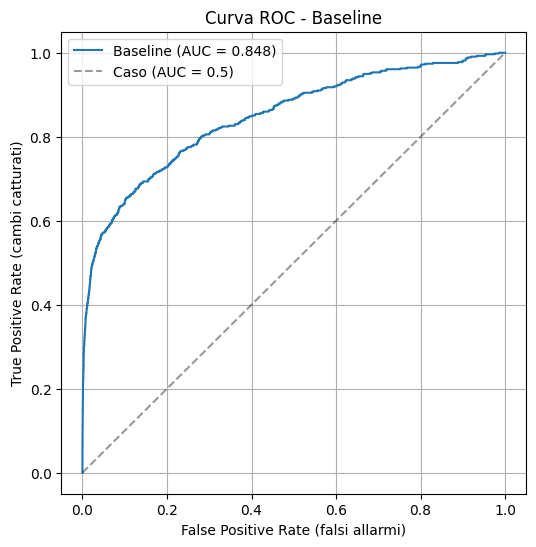

In [5]:
# 1. Scores of the network on the validation set
model.eval()
with torch.no_grad():
    val_logits = model(Xva.to(device))          # raw logits
    val_probs = torch.sigmoid(val_logits).cpu().numpy()  # -> scores in (0, 1)

y_val_np = yva.numpy()

# 2. AUC: a single number that summarises the ROC curve
auc = roc_auc_score(y_val_np, val_probs)
print(f"AUC (validation): {auc:.4f}")

# 3. ROC curve: TPR against FPR for all thresholds
fpr, tpr, thresholds = roc_curve(y_val_np, val_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Baseline (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Caso (AUC = 0.5)")
plt.xlabel("False Positive Rate (falsi allarmi)")
plt.ylabel("True Positive Rate (cambi catturati)")
plt.title("Curva ROC - Baseline")
plt.legend()
plt.grid(True)
plt.show()

### Precision and recall at three thresholds

In [6]:
# Precision, recall and number of windows classified as positive at three thresholds,
# to see the trade-off between the two
for soglia in [0.3, 0.5, 0.7]:
    pred = (val_probs >= soglia).astype(int)
    prec = precision_score(y_val_np, pred, zero_division=0)
    rec  = recall_score(y_val_np, pred, zero_division=0)
    n_allarmi = int(pred.sum())
    print(f"soglia {soglia:.1f} | precision: {prec:.3f} | recall: {rec:.3f} "
          f"| allarmi totali: {n_allarmi}")

soglia 0.3 | precision: 0.086 | recall: 0.686 | allarmi totali: 4248
soglia 0.5 | precision: 0.135 | recall: 0.606 | allarmi totali: 2406
soglia 0.7 | precision: 0.210 | recall: 0.548 | allarmi totali: 1393


### Precision–recall curve and AP

Average Precision (AP): 0.3596
Frazione di positivi (baseline casuale): 0.0185


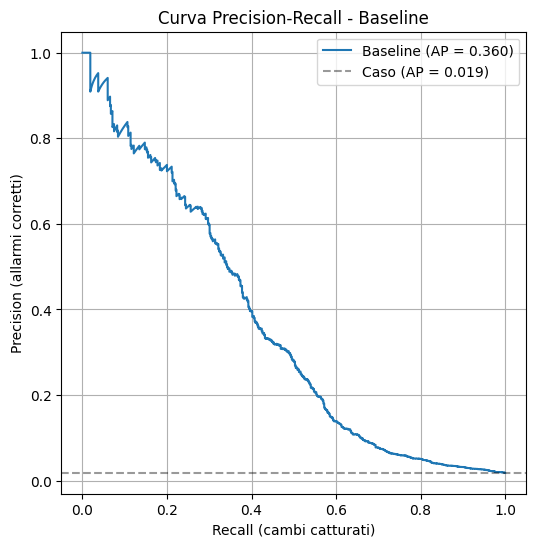

In [7]:
# Precision and recall for all thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_val_np, val_probs)

# Average precision: the counterpart of the AUC for the precision-recall curve
ap = average_precision_score(y_val_np, val_probs)

# The reference level of the PR curve is NOT 0.5 but the fraction of positive windows
frazione_positivi = y_val_np.mean()

print(f"Average Precision (AP): {ap:.4f}")
print(f"Frazione di positivi (baseline casuale): {frazione_positivi:.4f}")

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label=f"Baseline (AP = {ap:.3f})")
plt.axhline(frazione_positivi, color="k", linestyle="--", alpha=0.4,
            label=f"Caso (AP = {frazione_positivi:.3f})")
plt.xlabel("Recall (cambi catturati)")
plt.ylabel("Precision (allarmi corretti)")
plt.title("Curva Precision-Recall - Baseline")
plt.legend()
plt.grid(True)
plt.show()